# Milestone 3: Initial Results and Coding

**Project:** Transportation Sustainability and Vehicle Emissions Prediction  
**Objective:** This notebook shows the proof-of-concept pipeline for predicting vehicle CO₂ emissions using the Canadian Fuel Consumption Ratings dataset. The notebook covers data loading, descriptive analysis, preprocessing, baseline modelling, model comparison, validation checks, and initial interpretation.

## 1. Import Libraries

This code imports the main Python libraries used in the notebook. Pandas and NumPy are used for data handling, Matplotlib and Seaborn are used for visualization, and scikit-learn is used for splitting the data, preprocessing, training models, and calculating regression metrics.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## 2. Data Loading and Initial Verification

In [2]:
!git clone https://github.com/IndrajeetSingh121/CIND820-CO2-Emission-Prediction.git

Cloning into 'CIND820-CO2-Emission-Prediction'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 236 (delta 47), reused 1 (delta 1), pack-reused 157 (from 1)
Receiving objects: 100% (236/236), 17.15 MiB | 20.28 MiB/s, done.
Resolving deltas: 100% (116/116), done.


In [3]:
%cd CIND820-CO2-Emission-Prediction/Notebooks

/content/CIND820-CO2-Emission-Prediction/Notebooks


In [4]:
from pathlib import Path
import pandas as pd

data_path = Path("../Dataset/my2015-2024-fuel-consumption-ratings.csv")

df = pd.read_csv(data_path)

df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN


In [5]:
# Dataset dimensions
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(10060, 15)


In [6]:
# Display columns
print(df.columns.tolist())

['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)', 'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


### Initial Verification

The dataset was successfully loaded into the Python environment. It contains approximately 10,060 observations and 15 variables describing vehicle specifications, fuel consumption measures, and environmental performance indicators for Canadian light-duty vehicles between 2015 and 2024.

## 3. Descriptive Statistics

In [7]:
numerical_columns = df.select_dtypes(include=np.number)
descriptive_stats = pd.DataFrame({
    "Mean": numerical_columns.mean(),
    "Median": numerical_columns.median(),
    "Mode": numerical_columns.mode().iloc[0],
    "Variance": numerical_columns.var()})
print("Descriptive Statistics:")
print(descriptive_stats)

Descriptive Statistics:
                             Mean  Median    Mode     Variance
Model year            2019.242048  2019.0  2015.0     8.032172
Engine size (L)          3.144901     3.0     2.0     1.795627
Cylinders                5.618390     6.0     4.0     3.519037
City (L/100 km)         12.483012    12.1    10.8    11.590576
Highway (L/100 km)       9.142744     8.9     7.8     4.746595
Combined (L/100 km)     10.979672    10.7     9.4     7.887565
Combined (mpg)          27.436282    26.0    25.0    53.527802
CO2 emissions (g/km)   253.710338   250.0   242.0  3657.249421
CO2 rating               4.617443     5.0     5.0     2.479879
Smog rating              4.816509     5.0     5.0     3.181918


The descriptive statistics show that the dataset has enough variation for predictive modelling. CO₂ emissions and fuel consumption variables have larger spread than the rating variables, which means vehicles differ noticeably in environmental performance. This variation is useful because the model needs differences in the predictors to learn how vehicle characteristics relate to emissions.


## 4. Visual Analysis: Distributions, Patterns, and Outliers

The following histograms and boxplots are used to identify patterns, skewness, and possible outliers. This satisfies the Milestone 3 requirement to go beyond listing columns and characterize the dataset using visual evidence.

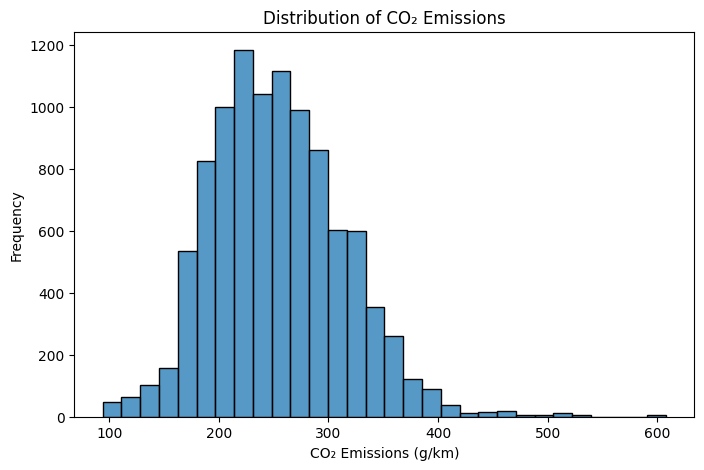

In [8]:
# Create a histogram to examine the distribution of CO2 emissions
plt.figure(figsize=(8,5))
sns.histplot(df['CO2 emissions (g/km)'], bins=30)
plt.title('Distribution of CO₂ Emissions')
plt.xlabel('CO₂ Emissions (g/km)')
plt.ylabel('Frequency')
plt.show()

The histogram shows that CO₂ emissions vary across the vehicles included in the dataset. This variation indicates that the target variable contains a broad range of values, making it suitable for developing and evaluating regression models.

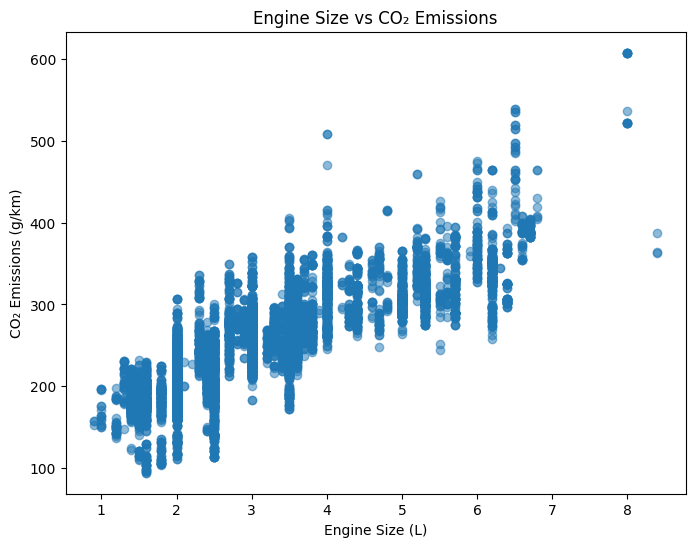

In [9]:
# Scatter Plot: Engine Size vs CO₂ Emissions
plt.figure(figsize=(8,6))
plt.scatter(df['Engine size (L)'], df['CO2 emissions (g/km)'], alpha=0.5)
plt.title('Engine Size vs CO₂ Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()

The scatter plot shows a positive relationship between engine size and CO₂ emissions. Vehicles with larger engine sizes generally produce higher CO₂ emissions, although some variation exists among vehicles with similar engine sizes. This indicates that engine size is an important predictor and was retained for model development.

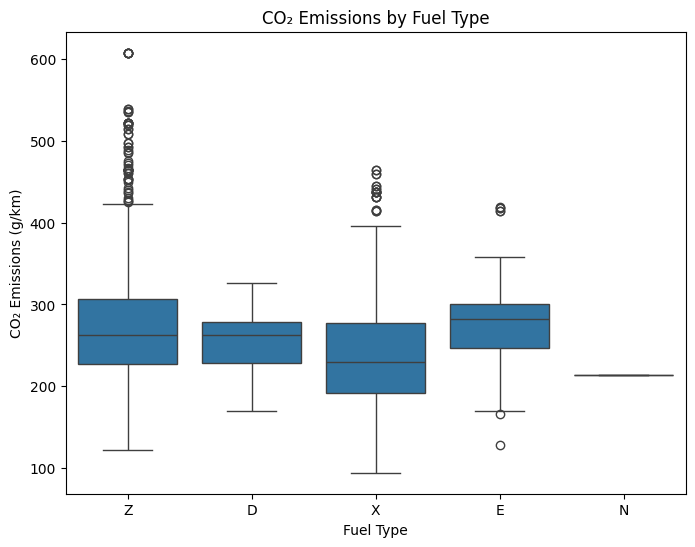

In [10]:
# Create the boxplot to identify potential outliers
plt.figure(figsize=(8,6))
sns.boxplot(x='Fuel type', y='CO2 emissions (g/km)', data=df)
plt.title('CO₂ Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show() # Display the boxplot

The boxplot shows differences in CO₂ emissions across the various fuel types. These differences indicate that fuel type influences vehicle emissions and should be retained as a predictor variable during model development.

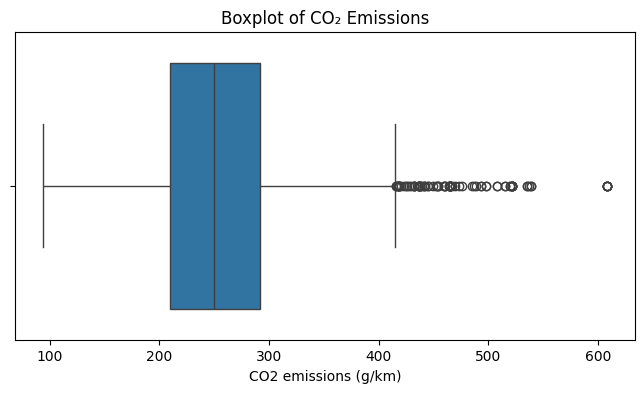

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['CO2 emissions (g/km)'])
plt.title('Boxplot of CO₂ Emissions')
plt.show()

The boxplot identifies several high-emission observations within the dataset. These values were retained because they represent genuine vehicle records and provide useful information for training the prediction models.

## Unusual Patterns, Trends, and Outliers**

The visual analysis showed that CO₂ emissions, fuel consumption, and engine size are moderately right-skewed. Most vehicles have lower to moderate values, while a smaller number have much higher values.

Boxplots identified several outliers, particularly for CO₂ emissions, fuel consumption, and engine size. These observations represent valid high-performance vehicles rather than data errors.

Therefore, the outliers were retained to preserve the full range of vehicle characteristics. However, their presence may influence model performance, making it important to compare Multiple Linear Regression and Random Forest Regression.

## 5. Data Preprocessing and Transformation
This section prepares the data for machine learning. The workflow follows a leakage-safe order: define the features and target, split the data into training and testing sets, check missing values, and then apply encoding and scaling using the training data. This order keeps the testing data unseen until final evaluation.

### 5.1 Feature and Target Selection

In [12]:
# Define target variable
target = df['CO2 emissions (g/km)']

# Select vehicle specification variables
features = df[
['Model year','Make','Vehicle class','Engine size (L)','Cylinders','Transmission','Fuel type']].copy()

print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (10060, 7)
Target shape: (10060,)


The main models use vehicle specification variables only. Fuel-consumption measures, CO₂ rating, and smog rating were excluded because they are closely related to CO₂ emissions and may inflate model performance. The individual vehicle model name was also excluded because it contains many categories and may cause the models to memorize specific vehicles.

### 5.2 Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split
# Split data before preprocessing
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8048, 7)
Testing data: (2012, 7)


A random 80:20 holdout split was used. Eighty percent of the records were used for model training, while twenty percent were kept as unseen testing data. A random split was appropriate because the project predicts emissions from vehicle specifications rather than forecasting future model years. The split was completed before encoding and scaling.

### 5.3 Missing Value Check



In [14]:
# Check missing values in selected features
print("Missing values in training data:")
print(X_train.isnull().sum())

print("\nTotal missing values in training data:", X_train.isnull().sum().sum())

print("Total missing values in testing data:", X_test.isnull().sum().sum())

Missing values in training data:
Model year         0
Make               0
Vehicle class      0
Engine size (L)    0
Cylinders          0
Transmission       0
Fuel type          0
dtype: int64

Total missing values in training data: 0
Total missing values in testing data: 0


The selected predictor variables did not contain missing values. Therefore, median imputation was not required for the main models.

### 5.4 Categorical Encoding

In [15]:
# Convert categorical variables into dummy variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies( X_test, drop_first=True)

# Match training and testing columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Training data after encoding:", X_train.shape)

print("Testing data after encoding:", X_test.shape)



Training data after encoding: (8048, 89)
Testing data after encoding: (2012, 89)


Categorical variables were converted using one-hot encoding. This method was used because make, vehicle class, transmission, and fuel type do not have a natural order.

### 5.5 Numerical Scaling

StandardScaler is applied to numerical variables after the train-test split. The scaler is fitted on the training data and then applied to the test data. This prevents data leakage and makes numerical variables with different units more comparable during model training.

In [16]:
# Select numerical columns
numeric_columns = ['Model year', 'Engine size (L)', 'Cylinders']

from sklearn.preprocessing import StandardScaler
# Standardize numerical variables
scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

# Display scaled values
X_train[numeric_columns].head()

,Model year,Engine size (L),Cylinders
8014,0.967425,-0.112870,0.197787
8318,0.967425,0.186628,0.197787
1544,-1.147430,-1.235987,-0.868383
8290,0.967425,-0.861614,-0.868383
1718,-1.147430,-0.562117,-0.868383


StandardScaler was fitted using the training data and then applied to the testing data. This ensures that the testing data does not influence the scaling process.

### 5.6 Final Preprocessing Check

In [17]:
print("Final training data shape:", X_train.shape)
print("Final testing data shape:", X_test.shape)

print("Missing values in training data:", X_train.isnull().sum().sum())
print("Missing values in testing data:", X_test.isnull().sum().sum())

Final training data shape: (8048, 89)
Final testing data shape: (2012, 89)
Missing values in training data: 0
Missing values in testing data: 0


At this stage, the dataset is ready for model development.

## 6. Model Development and Evaluation


In [18]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

LinearRegression()

The trained model is then used to predict CO₂ emissions for the testing dataset. The first few predictions are printed to show that the model is producing output.


In [19]:
# Predict on testing data
y_pred = lr_model.predict(X_test)

# Display first few predictions
print(y_pred[:5])

[171.79721661 249.41738031 260.60023971 243.01207691 205.37843874]


### 6.2 Baseline Model Metrics

The model is evaluated using MAE, RMSE, and R². These metrics are selected because this is a regression problem. MAE and RMSE measure prediction error in g/km, while R² shows how much variation in CO₂ emissions is explained by the model.

In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np # Import numpy for square root function

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error( y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 17.091308793478277
RMSE: 22.888462574285928
R2 Score: 0.8528172086252866


### 6.3 Actual vs Predicted Plot for Baseline Model

This scatter plot compares actual CO₂ emissions with predicted CO₂ emissions. A strong model should place most points close to a diagonal pattern, meaning predicted values are close to the true values.


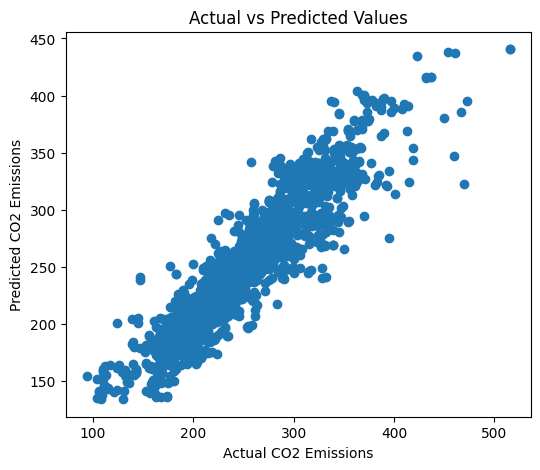

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")

plt.title("Actual vs Predicted Values")
plt.show()

The plot provides visual evidence that the baseline model is producing interpretable results. Points close to the diagonal trend show that the model predicts most observations accurately, while points farther away represent larger prediction errors.

**Linear Regression Assumption Test**

In [22]:
# Calculate residuals
residuals = y_test - y_pred
residuals.head()

,CO2 emissions (g/km)
8294,10.202783
3131,-21.417380
2777,-14.600240
9305,-28.012077
107,-12.378439


Residuals are calculated as actual values minus predicted values. Residual analysis helps identify whether the model is making systematic errors.

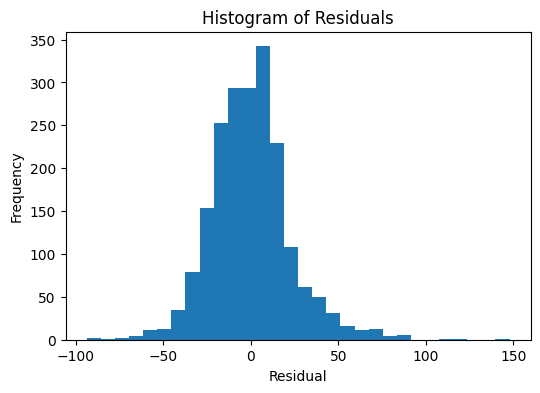

In [23]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

The residual histogram shows whether prediction errors are centered around zero. A concentration near zero suggests that most errors are small.

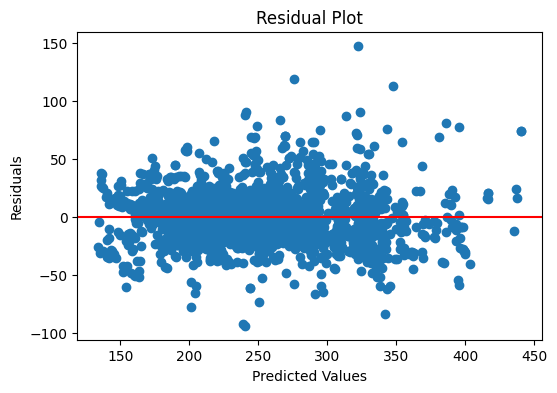

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

The residual plot checks whether errors are randomly scattered around zero. A random pattern suggests that the model has captured the main relationship between predictors and CO₂ emissions.


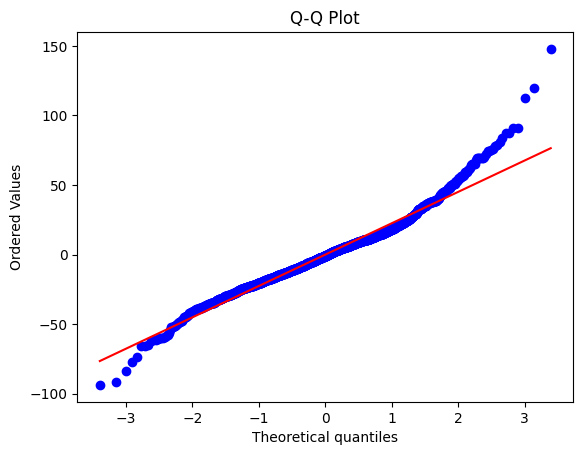

In [25]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")

plt.show()

The Q-Q plot checks whether residuals are approximately normally distributed. Minor deviations at the ends are expected, but a mostly straight pattern supports the baseline model as a reasonable starting point.


## 9. Comparison Model: Random Forest Regression

Random Forest Regression is developed as a second model to compare with the baseline. This model is useful because it can capture non-linear relationships and interactions between vehicle variables without assuming a straight-line relationship.

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

The Random Forest model is trained using the same processed training dataset as Linear Regression. Using the same train-test split makes the model comparison fair.


In [27]:
# Predict on test data
rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:5])

[176.90283333 226.95956254 253.69       228.396      205.60432656]


### 9.1 Random Forest Metrics

In [28]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np # Import numpy for square root function

rf_mae = mean_absolute_error(y_test, rf_predictions)

# Calculate MSE first, then take the square root for RMSE
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 9.627359956017445
RMSE: 14.507343281483367
R2 Score: 0.9408711317188369


## 10. Random Forest Hyperparameter Tuning

The initial Random Forest used manually selected settings. GridSearchCV was used to test different numbers of trees, tree depths, minimum split sizes, and minimum leaf sizes. Five-fold cross-validation was applied using the training data only. The parameter combination with the lowest cross-validation RMSE was selected.

In [29]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [30]:
# Define parameter values to test
parameter_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20],'min_samples_split': [2, 5],
    'min_samples_leaf': [1,2]}

In [31]:
# Create Random Forest model for tuning
rf_tuning_model = RandomForestRegressor(random_state=42)

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=parameter_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1)

# Fit using training data only
grid_search.fit(X_train, y_train)

# Display the best results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation RMSE:
15.55070040499395


The number of trees was tested to examine prediction stability. Maximum depth was tested to control the complexity of each tree. Minimum split size and minimum leaf size were tested to reduce overfitting. The final settings were selected based on the lowest five-fold cross-validation RMSE.

### 11. Tuned Random Forest Evaluation

In [32]:
# Select the best tuned Random Forest model
best_rf_model = grid_search.best_estimator_

# Make predictions
rf_train_predictions = best_rf_model.predict(X_train)
rf_test_predictions = best_rf_model.predict(X_test)

# Calculate training metrics
rf_train_mae = mean_absolute_error(y_train, rf_train_predictions)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_predictions))
rf_train_r2 = r2_score( y_train, rf_train_predictions)

# Calculate testing metrics
rf_test_mae = mean_absolute_error(y_test, rf_test_predictions)
rf_test_rmse = np.sqrt( mean_squared_error(y_test, rf_test_predictions))
rf_test_r2 = r2_score(y_test, rf_test_predictions)

# Display results
print("Tuned Random Forest Results")

print("\nTraining Performance")
print("MAE:", rf_train_mae)
print("RMSE:", rf_train_rmse)
print("R2 Score:", rf_train_r2)

print("\nTesting Performance")
print("MAE:", rf_test_mae)
print("RMSE:", rf_test_rmse)
print("R2 Score:", rf_test_r2)


Tuned Random Forest Results

Training Performance
MAE: 7.713786296928301
RMSE: 11.578878119538556
R2 Score: 0.9635704353285957

Testing Performance
MAE: 9.776943669468837
RMSE: 14.355533850376036
R2 Score: 0.942102143373654


The tuned Random Forest model was evaluated using both the training and testing datasets. Training metrics show how well the model learned from the training data, while testing metrics measure its ability to predict unseen vehicle records. The testing results are used as the primary indicators of model performance.

## 12. Random Forest Overfitting Assessment

The training and testing performance of the tuned Random Forest model was compared to determine whether the model overfitted the training data. A large difference between the two sets of results would indicate poor generalization to unseen vehicle records.

In [33]:
# Compare training and testing performance
print("Training R2 :", round(rf_train_r2, 4))
print("Testing R2  :", round(rf_test_r2, 4))

print()

print("Training RMSE :", round(rf_train_rmse, 4))
print("Testing RMSE  :", round(rf_test_rmse, 4))

print()

print("Difference in R2 :", round(rf_train_r2 - rf_test_r2, 4))

Training R2 : 0.9636
Testing R2  : 0.9421

Training RMSE : 11.5789
Testing RMSE  : 14.3555

Difference in R2 : 0.0215


The training and testing performance of the tuned Random Forest model was compared to assess overfitting. The training R² was 0.9636, while the testing R² was 0.9421, resulting in a difference of 0.0215. The testing RMSE was slightly higher than the training RMSE, which is expected because the model was evaluated on unseen observations.

The relatively small difference between the training and testing results suggests that the tuned Random Forest did not substantially overfit the training data and generalized well to new vehicle records.

## 13. Random Forest Diagnostics

### 13.1 Actual versus predicted plot

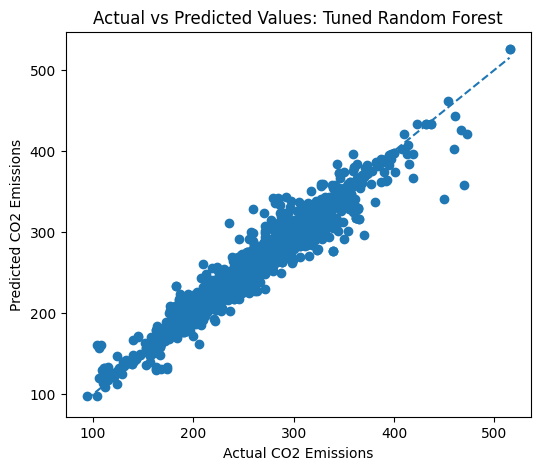

In [34]:
# Actual versus predicted plot for tuned Random Forest
plt.figure(figsize=(6, 5))
plt.scatter(y_test, rf_test_predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")

plt.title("Actual vs Predicted Values: Tuned Random Forest")

plt.show()

The actual-versus-predicted plot compares the tuned Random Forest predictions with the observed CO₂ emissions values. Points close to the diagonal line indicate more accurate predictions. Points farther from the line represent vehicle records with larger prediction errors.

### 13.2 Residual plot

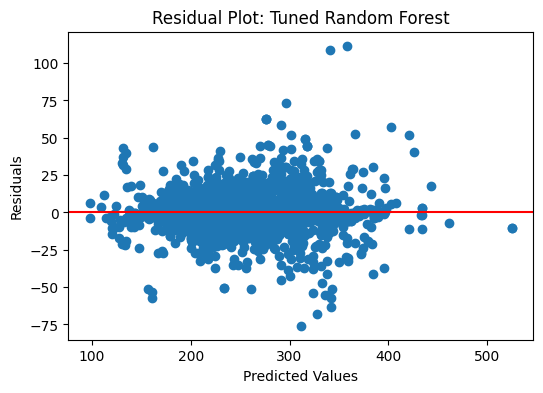

In [35]:
# Calculate residuals for tuned Random Forest
rf_residuals = (y_test - rf_test_predictions)

# Create residual plot
plt.figure(figsize=(6, 4))

plt.scatter(rf_test_predictions, rf_residuals)
plt.axhline(y=0, color='red')
plt.title("Residual Plot: Tuned Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

The residual plot examines whether the tuned Random Forest systematically overpredicts or underpredicts emissions. Residuals generally centred around zero suggest limited systematic bias. Larger residuals identify vehicles that were more difficult for the model to predict.

## 14. Random Forest Feature Importance

In [36]:
# Create feature importance table
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance':
        best_rf_model.feature_importances_})

# Sort features from highest to lowest importance
feature_importance = (feature_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True))

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
0,Engine size (L),0.703938
1,Cylinders,0.086320
2,Model year,0.018693
3,Transmission_AV,0.015871
4,Vehicle class_Mid-size,0.013034
5,Transmission_AM7,0.012712
6,Vehicle class_Sport utility vehicle: Standard,0.010432
7,Fuel type_Z,0.009547
8,Vehicle class_Sport utility vehicle: Small,0.007982
9,Make_Ford,0.007902


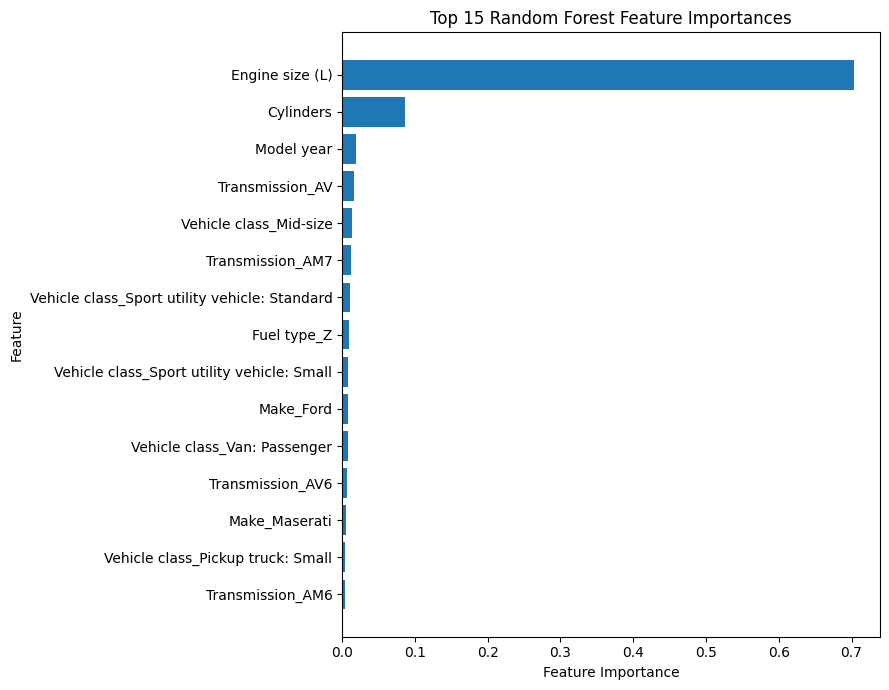

In [37]:
# Select top 15 features
top_features = (feature_importance.head(15).sort_values(by='Importance', ascending=True))

# Create feature importance chart
plt.figure(figsize=(9, 7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

Engine size was the most important predictor in the tuned Random Forest, followed by cylinder count. Model year, transmission categories, vehicle class, fuel type, and selected manufacturers made smaller contributions. Feature importance describes how strongly the model used each predictor and should not be interpreted as proof that a variable directly causes higher emissions.

## 15. Final Model Comparison

In [38]:
# Create final model comparison table
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Tuned Random Forest'],
    'MAE': [mae, rf_test_mae],
    'RMSE': [rmse, rf_test_rmse],
    'R2': [r2, rf_test_r2]})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,17.091309,22.888463,0.852817
1,Tuned Random Forest,9.776944,14.355534,0.942102


### 15.1 Model Comparison Interpretation

The performance of Multiple Linear Regression and the tuned Random Forest Regression was compared using MAE, RMSE, and R² on the testing dataset.

Linear Regression achieved an R² of approximately 0.853, while the tuned Random Forest achieved an R² of approximately 0.942. The Random Forest also produced lower prediction errors, indicating that it captured the relationship between vehicle characteristics and CO₂ emissions more effectively.

The improved performance suggests that non-linear relationships and interactions among vehicle specifications were important for predicting vehicle emissions. Therefore, the tuned Random Forest was selected as the final model for this project.

# Appendix A: Features Used in the Final Models

## Target Variable

- CO₂ emissions (g/km)

## Multiple Linear Regression Features

- Model year
- Make
- Vehicle class
- Engine size (L)
- Cylinders
- Transmission
- Fuel type

## Tuned Random Forest Features

- Model year
- Make
- Vehicle class
- Engine size (L)
- Cylinders
- Transmission
- Fuel type

## Variables Excluded from the Main Models

- Vehicle model
- Fuel consumption city (L/100 km)
- Fuel consumption highway (L/100 km)
- Fuel consumption combined (L/100 km)
- Fuel consumption combined (mpg)
- CO₂ rating
- Smog rating

# 16. Model Stability Using Cross-Validation

The previous evaluation used an 80:20 random holdout split. To determine whether the models produce consistent results across different data partitions, five-fold cross-validation was performed.

Cross-validation repeatedly trains and evaluates the models on different subsets of the training data. The average RMSE and its standard deviation are used to assess model stability. A lower average RMSE indicates better predictive performance, while a smaller standard deviation indicates more consistent performance across different folds.

In [39]:
# Import cross-validation
from sklearn.model_selection import cross_val_score

# Linear Regression Cross Validation

lr_cv = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error")

lr_cv = -lr_cv

print("Linear Regression RMSE")
print(lr_cv)

print("\nAverage RMSE:", lr_cv.mean())
print("Standard Deviation:", lr_cv.std())

Linear Regression RMSE
[22.27659425 22.6859492  23.47014938 22.66255955 22.76101565]

Average RMSE: 22.77125360618099
Standard Deviation: 0.3879018524538762


In [40]:
# Tuned Random Forest Cross Validation

rf_cv = cross_val_score(
    best_rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)

rf_cv = -rf_cv

print("Random Forest RMSE")
print(rf_cv)

print("\nAverage RMSE:", rf_cv.mean())
print("Standard Deviation:", rf_cv.std())

Random Forest RMSE
[15.03801027 16.3118989  15.77141995 14.50480261 16.1273703 ]

Average RMSE: 15.55070040499395
Standard Deviation: 0.6807997943053974


In [41]:
# Stability comparison table

stability_results = pd.DataFrame({

    "Model":["Multiple Linear Regression", "Tuned Random Forest"],

    "Mean RMSE":[lr_cv.mean(), rf_cv.mean()],

    "RMSE Standard Deviation":[lr_cv.std(), rf_cv.std()]})

stability_results

,Model,Mean RMSE,RMSE Standard Deviation
0,Multiple Linear Regression,22.771254,0.387902
1,Tuned Random Forest,15.550700,0.680800


### Interpretation

Five-fold cross-validation was used to evaluate model stability. The Tuned Random Forest achieved a lower average RMSE than Multiple Linear Regression while maintaining consistent performance across all validation folds. These results indicate that the Tuned Random Forest generalized better and was selected as the final model.

# 17. Model Efficiency

Model efficiency was evaluated by measuring the time required to train each model and generate predictions on the testing dataset.

Training time shows the computational cost required to fit the model, while prediction time shows how quickly the model can produce results for new vehicle records. Lower times indicate greater computational efficiency.

In [42]:
# Import time module
import time

# Measure Linear Regression training time

lr_start_train = time.time()
lr_efficiency_model = LinearRegression()
lr_efficiency_model.fit(X_train, y_train)
lr_end_train = time.time()
lr_training_time = (lr_end_train - lr_start_train)

# Measure Linear Regression prediction time

lr_start_prediction = time.time()
lr_efficiency_predictions = (lr_efficiency_model.predict(X_test))
lr_end_prediction = time.time()
lr_prediction_time = (lr_end_prediction - lr_start_prediction)

print("Linear Regression Training Time:", lr_training_time)
print("Linear Regression Prediction Time:", lr_prediction_time)

Linear Regression Training Time: 0.11378049850463867
Linear Regression Prediction Time: 0.004758119583129883


In [43]:
import time
# Measure Tuned Random Forest training time

rf_start_train = time.time()
rf_efficiency_model = RandomForestRegressor(**grid_search.best_params_, random_state=42)
rf_efficiency_model.fit(X_train, y_train)
rf_end_train = time.time()
rf_training_time = (rf_end_train - rf_start_train)

# Measure Tuned Random Forest prediction time

rf_start_prediction = time.time()
rf_efficiency_predictions = (rf_efficiency_model.predict(X_test))
rf_end_prediction = time.time()
rf_prediction_time = (rf_end_prediction - rf_start_prediction)

print("Tuned Random Forest Training Time:", rf_training_time)
print("Tuned Random Forest Prediction Time:", rf_prediction_time)

Tuned Random Forest Training Time: 7.276914119720459
Tuned Random Forest Prediction Time: 0.11822152137756348


In [44]:
# Create efficiency comparison table

efficiency_results = pd.DataFrame({

    "Model": ["Multiple Linear Regression", "Tuned Random Forest"],
    "Training Time (seconds)": [lr_training_time, rf_training_time],
    "Prediction Time (seconds)": [lr_prediction_time, rf_prediction_time]})

efficiency_results = efficiency_results.round(4)
efficiency_results

,Model,Training Time (seconds),Prediction Time (seconds)
0,Multiple Linear Regression,0.1138,0.0048
1,Tuned Random Forest,7.2769,0.1182


### Interpretation

Model efficiency was evaluated using training and prediction times. Multiple Linear Regression was computationally faster, while the Tuned Random Forest required more time due to the construction of multiple decision trees. Despite the higher computational cost, the Tuned Random Forest achieved better predictive performance, making it the preferred model for this study